In [ ]:
!pip install tensorflow
!pip install tensorflow-datasets


In [3]:
import pandas as pd

# Replace 'your_file.csv' with the actual filename after uploading
df = pd.read_csv('/content/heart_disease.csv')

# Check the first few rows of the dataset to verify it's loaded correctly
df.head()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.fillna(df.median(), inplace=True)


In [21]:
df.isnull().sum()

# Fill missing values (if any) with the mean of each column
df = df.fillna(df.mean())

# Normalize numerical features (scaled to 0-1 range)
scaler = StandardScaler()
X = df.drop('target', axis=1)
y = df['target']
X_scaled = scaler.fit_transform(X)

In [6]:
df = pd.get_dummies(df, drop_first=True)


In [15]:
# Drop rows with missing values
df = df.dropna()

# Alternatively, replace missing values with the column's median
df = df.fillna(df.median())


In [16]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('target', axis=1)  # Features excluding the target column
y = df['target']               # Target column (target is our binary classification)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122


In [17]:
X = pd.get_dummies(X, drop_first=True)


In [18]:
import tensorflow as tf

# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification output
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary of the model
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train the model for 20 epochs
model.fit(X_train, y_train, epochs=20, batch_size=32)


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7019 - loss: 0.6061
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8180 - loss: 0.4123 
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8661 - loss: 0.3342 
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8931 - loss: 0.3026 
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8970 - loss: 0.2858  
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9178 - loss: 0.2621 
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9182 - loss: 0.2355 
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9210 - loss: 0.2534 
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9188 - loss: 0.2220 
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9286 - loss: 0.2178 
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9030 - loss: 0.2440  
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy:

In [20]:
from sklearn.metrics import f1_score

# Evaluate the model's performance
loss, accuracy = model.evaluate(X_test, y_test)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert predictions to binary (0 or 1)
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate F1 score
f1 = f1_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8826 - loss: 0.1925  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy: 0.8829
F1 Score: 0.8868


In [22]:
df.isnull().sum()

# Fill missing values (if any) with the mean of each column
df = df.fillna(df.mean())

# Normalize numerical features (scaled to 0-1 range)
scaler = StandardScaler()
X = df.drop('target', axis=1)
y = df['target']
X_scaled = scaler.fit_transform(X)

In [23]:
from imblearn.over_sampling import SMOTE

# Handling class imbalance with SMOTE (if applicable)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


In [24]:
import tensorflow as tf

# Define the model
model = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_resampled.shape[1],)),
    tf.keras.layers.BatchNormalization(),  # Batch normalization for better training speed
    tf.keras.layers.Dropout(0.5),  # Dropout to prevent overfitting

    # Hidden Layers
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    # Output Layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model with an optimizer and loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Model Summary to check architecture
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [25]:
# Add EarlyStopping to monitor the validation loss
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_resampled, y_resampled, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5283 - loss: 0.9925 - val_accuracy: 0.6445 - val_loss: 0.6538
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6349 - loss: 0.7717 - val_accuracy: 0.7346 - val_loss: 0.6143
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6203 - loss: 0.7954 - val_accuracy: 0.7536 - val_loss: 0.5751
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6682 - loss: 0.7305 - val_accuracy: 0.7536 - val_loss: 0.5384
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7042 - loss: 0.6241 - val_accuracy: 0.7536 - val_loss: 0.5077
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7121 - loss: 0.5787 - val_accuracy: 0.7583 - val_loss: 0.4818
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7369 - loss: 0.5743 - val_accuracy: 0.7583 - val_loss: 0.4601
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: 0.6498 - val_accuracy: 0.7630 - val_loss

In [26]:
# Test data split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Evaluate model performance on the test set
loss, accuracy = model.evaluate(X_test, y_test)

# Make predictions
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

# Metrics
from sklearn.metrics import f1_score, classification_report
f1 = f1_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(classification_report(y_test, y_pred_binary))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8827 - loss: 0.2593 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Accuracy: 0.8957
F1 Score: 0.9076
              precision    recall  f1-score   support

         0.0       0.90      0.86      0.88        94
         1.0       0.89      0.92      0.91       117

    accuracy                           0.90       211
   macro avg       0.90      0.89      0.89       211
weighted avg       0.90      0.90      0.90       211



In [27]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [28]:
# Training the model
history = model.fit(
    X_train, y_train,                  # Training data
    epochs=50,                          # Number of epochs (can adjust based on performance)
    batch_size=32,                      # Batch size (can experiment with this)
    validation_split=0.2,               # Split data for validation (20% will be used for validation)
    callbacks=[early_stopping]          # Apply early stopping callback to avoid overfitting
)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8038 - loss: 0.4646 - val_accuracy: 0.9112 - val_loss: 0.2642
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8185 - loss: 0.4463 - val_accuracy: 0.9112 - val_loss: 0.2645
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8166 - loss: 0.4008 - val_accuracy: 0.9112 - val_loss: 0.2647
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8482 - loss: 0.3820 - val_accuracy: 0.9112 - val_loss: 0.2643
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8380 - loss: 0.3659 - val_accuracy: 0.9112 - val_loss: 0.2647
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8721 - loss: 0.3365 - val_accuracy: 0.9112 - val_loss: 0.2644
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8462 - loss: 0.3536 - val_accuracy: 0.9112 - val_loss: 0.2646
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8226 - loss: 0.3867 - val_accuracy: 0.9112 - val_loss

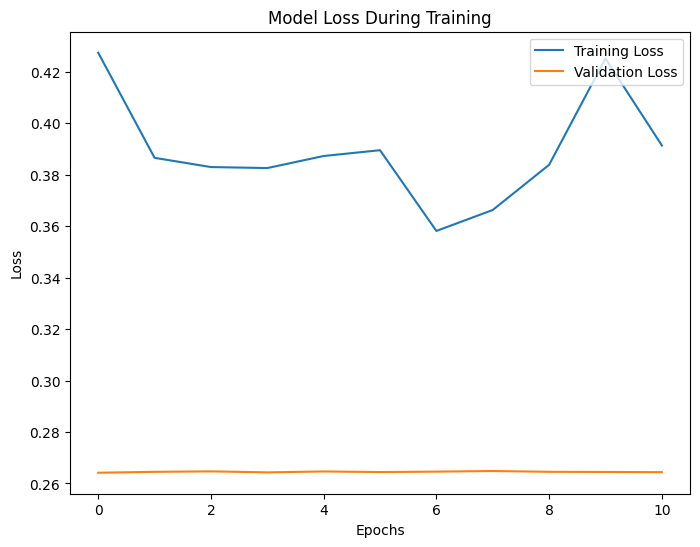

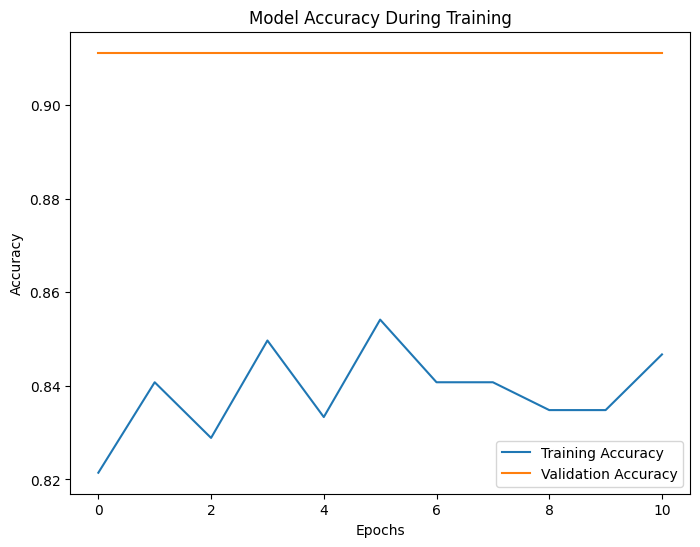

In [29]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training')
plt.legend(loc='upper right')
plt.show()

# Plot training & validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy During Training')
plt.legend(loc='lower right')
plt.show()


In [30]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print test performance metrics
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

# Predict on test data
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

# Classification report
from sklearn.metrics import f1_score, classification_report
print(f"F1 Score: {f1_score(y_test, y_pred_binary)}")
print(classification_report(y_test, y_pred_binary))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8827 - loss: 0.2588 


Test Loss: 0.24985234439373016
Test Accuracy: 0.8957346081733704
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
F1 Score: 0.907563025210084
              precision    recall  f1-score   support

         0.0       0.90      0.86      0.88        94
         1.0       0.89      0.92      0.91       117

    accuracy                           0.90       211
   macro avg       0.90      0.89      0.89       211
weighted avg       0.90      0.90      0.90       211



In [31]:
# Save the model to disk for future use
model.save("heart_disease_model.h5")
